In [15]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import time

In [16]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

In [17]:
BATCH_SIZE = 16

def preprocess(image, label):
    image = tf.image.resize(image, (299, 299))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [18]:
base_model = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(299, 299, 3)
)
base_model.trainable = False

In [19]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 8, 8, 2048)        21802784  
                                                                 
 global_average_pooling2d_2   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_4 (Dense)             (None, 256)               524544    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_5 (Dense)             (None, 10)                2570      
                                                                 
Total params: 22,329,898
Trainable params: 527,114
Non-trainable params: 21,802,784
____________________________________

In [21]:
start_time = time.time()

history = model.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds,
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining Time: {training_time:.2f} seconds")

Epoch 1/5
3125/3125 [==============================] - 180s 54ms/step - loss: 0.7779 - accuracy: 0.7402 - val_loss: 0.5451 - val_accuracy: 0.8156
Epoch 2/5
3125/3125 [==============================] - 172s 53ms/step - loss: 0.5583 - accuracy: 0.8096 - val_loss: 0.4969 - val_accuracy: 0.8279
Epoch 3/5
3125/3125 [==============================] - 168s 53ms/step - loss: 0.5043 - accuracy: 0.8271 - val_loss: 0.4700 - val_accuracy: 0.8381
Epoch 4/5
3125/3125 [==============================] - 170s 52ms/step - loss: 0.4707 - accuracy: 0.8403 - val_loss: 0.4536 - val_accuracy: 0.8438
Epoch 5/5
3125/3125 [==============================] - 169s 52ms/step - loss: 0.4433 - accuracy: 0.8461 - val_loss: 0.4646 - val_accuracy: 0.8393

Training Time: 859.23 seconds


In [22]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 83.93%
Test Loss: 0.4646


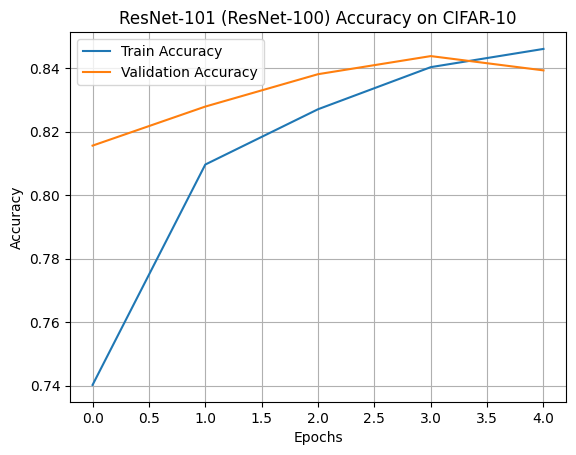

In [23]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('ResNet-101 (ResNet-100) Accuracy on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()

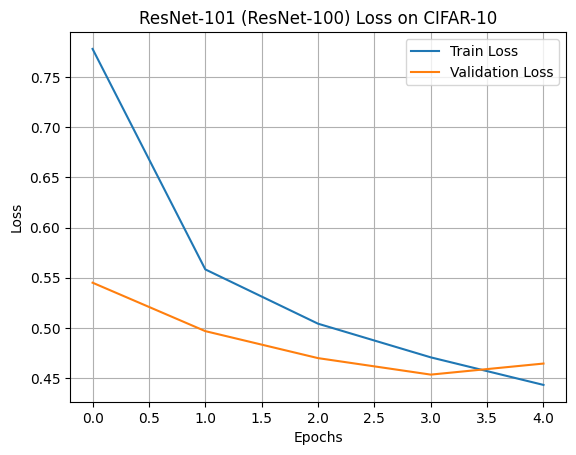

In [24]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ResNet-101 (ResNet-100) Loss on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
print(f"Total Parameters: {model.count_params():,}")

Total Parameters: 22,329,898
